# 14 — Choice-Vigor Dissociation

Core question: choosing hard cookies and pressing hard are independent.
β (threat bias) suppresses choice but not motor execution, creating four behavioral profiles
with distinct parameter signatures, affect, and outcomes.

In [1]:
# ── SETUP ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
VIGOR_PREP = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_prep'
STAGE2     = ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage2_trial_processing_20260317_094210'
STAGE5     = ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage5_filtered_data_20260317_094210'
STATS_DIR  = ROOT / 'results' / 'stats'
FIGS_DIR   = ROOT / 'results' / 'figs'; FIGS_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

# ── Load keypresses + trial info ──
kp = pd.read_parquet(VIGOR_PREP / 'keypress_events.parquet')
pm = pd.read_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet')
subj_cap = pd.read_csv(VIGOR_PROC / 'subject_press_capacity.csv', index_col='subj')['capacity_pps']

# Original encounterTime (trial-start-relative)
with open(STAGE2 / 'processed_trials.pkl', 'rb') as f:
    pt = pickle.load(f)
pt['subj'] = pt.groupby('participantID').ngroup() + 1
pt['trial'] = pt.groupby('subj').cumcount()
enc_lookup = pt[['subj','trial','encounterTime']].rename(columns={'encounterTime':'enc_abs'})

trial_info = pm[['subj','trial','threat','isAttackTrial','outcome','choice',
                  'effort_H','distance_H','trialEndTime']].copy()

# Model params
param_df = pd.DataFrame({
    p: pd.read_csv(STATS_DIR / f'FET_Exp_Bias_{p}_params.csv')
       .rename(columns={'subject':'subj'}).set_index('subj')['median']
    for p in ['z','k','beta']
})
param_df.columns = ['z','kappa','beta']

# Affect
trait_affect = pd.read_csv(STATS_DIR / 'affect_trait_scores.csv').set_index('subj')

# Psych
psych = pd.read_csv(STAGE5 / 'psych.csv').set_index('subj')

print('Data loaded.')

Data loaded.


In [2]:
# ── BUILD SUBJECT-LEVEL CHOICE × VIGOR ────────────────────────────────────────

# CHOICE: proportion of trials choosing the high-effort cookie
choice_stats = trial_info.groupby('subj')['choice'].mean().to_frame('p_high')

# VIGOR: pre-encounter pressing rate (capacity-normalized, choice-ratio adjusted)
kp_merged = kp.merge(trial_info, on=['subj','trial'], how='inner')
kp_merged = kp_merged.merge(enc_lookup, on=['subj','trial'], how='inner')
kp_merged = kp_merged.merge(subj_cap.to_frame('capacity'), left_on='subj', right_index=True)

enc = kp_merged['enc_abs']
kp_pre = kp_merged[(kp_merged['t'] >= enc - 2) & (kp_merged['t'] < enc)]

trial_presses = kp_pre.groupby(['subj','trial']).size().reset_index(name='pre_presses')
trial_presses = trial_presses.merge(trial_info[['subj','trial','choice','threat',
                                                  'isAttackTrial','outcome','distance_H']], 
                                     on=['subj','trial'])
trial_presses = trial_presses.merge(subj_cap.to_frame('capacity'), left_on='subj', right_index=True)
trial_presses['pre_rate'] = (trial_presses['pre_presses'] / 2.0) / trial_presses['capacity']
ch_mean = trial_presses.groupby('choice')['pre_rate'].transform('mean')
trial_presses['pre_rate_adj'] = trial_presses['pre_rate'] / ch_mean

subj_vigor = trial_presses.groupby('subj')['pre_rate_adj'].mean().to_frame('mean_vigor')

# Escape rate
escape = (trial_info[trial_info['isAttackTrial']==1]
          .groupby('subj')['outcome']
          .apply(lambda x: (x==0).mean())
          .to_frame('escape_rate'))

# Earnings
trial_info_earn = trial_info.copy()
trial_info_earn['reward'] = np.where(trial_info_earn['choice']==1, 5, 1)
trial_info_earn['net'] = np.where(trial_info_earn['outcome']==1, -5, trial_info_earn['reward'])
earnings = trial_info_earn.groupby('subj')['net'].sum().to_frame('total_earnings')

# ── Combine ──
subj_df = (choice_stats.join(subj_vigor).join(param_df).join(escape)
           .join(earnings).join(trait_affect[['trait_anx','trait_conf']]))

# Calibration
feelings = pd.read_csv(STAGE5 / 'feelings.csv')
feelings = feelings.rename(columns={'attackingProb':'p_threat','questionLabel':'affect_type',
                                     'response':'rating'})
from scipy.stats import spearmanr
calib = {}
for subj, grp in feelings.groupby('subj'):
    for atype in ['anxiety','confidence']:
        sub = grp[grp['affect_type']==atype]
        if len(sub) >= 5:
            r, _ = spearmanr(sub['p_threat'], sub['rating'])
            calib[(subj, atype)] = r
calib_df = pd.Series(calib).unstack()
calib_df.columns = ['anx_calib','conf_calib']
subj_df = subj_df.join(calib_df)

# Psych
psych_cols = ['DASS21_Anxiety','DASS21_Stress','DASS21_Depression','OASIS_Total',
              'PHQ9_Total','AMI_Total','MFIS_Physical','STICSA_Total']
subj_df = subj_df.join(psych[psych_cols])

subj_df = subj_df.dropna(subset=['p_high','mean_vigor','z','kappa','beta'])

# Z-score
subj_df['choice_z'] = (subj_df['p_high'] - subj_df['p_high'].mean()) / subj_df['p_high'].std()
subj_df['vigor_z'] = (subj_df['mean_vigor'] - subj_df['mean_vigor'].mean()) / subj_df['mean_vigor'].std()

# Quadrants
subj_df['quadrant'] = 'XX'
subj_df.loc[(subj_df['choice_z'] > 0) & (subj_df['vigor_z'] > 0), 'quadrant'] = 'HH'
subj_df.loc[(subj_df['choice_z'] > 0) & (subj_df['vigor_z'] <= 0), 'quadrant'] = 'HL'
subj_df.loc[(subj_df['choice_z'] <= 0) & (subj_df['vigor_z'] > 0), 'quadrant'] = 'LH'
subj_df.loc[(subj_df['choice_z'] <= 0) & (subj_df['vigor_z'] <= 0), 'quadrant'] = 'LL'

QUAD_COLORS = {'HH':'#4CAF50', 'HL':'#FF9800', 'LH':'#2196F3', 'LL':'#9E9E9E'}
QUAD_LABELS = {'HH':'Choose hard, press hard', 'HL':'Choose hard, press soft',
               'LH':'Choose easy, press hard', 'LL':'Choose easy, press soft'}

print(f'N = {len(subj_df)}')
r, p = stats.pearsonr(subj_df['p_high'], subj_df['mean_vigor'])
print(f'Choice × Vigor: r={r:+.3f}, p={p:.3f}')
print(f'\nQuadrant counts:')
for q in ['HH','HL','LH','LL']:
    print(f'  {q} ({QUAD_LABELS[q]}): N={(subj_df["quadrant"]==q).sum()}')

N = 293
Choice × Vigor: r=-0.018, p=0.764

Quadrant counts:
  HH (Choose hard, press hard): N=63
  HL (Choose hard, press soft): N=83
  LH (Choose easy, press hard): N=78
  LL (Choose easy, press soft): N=69


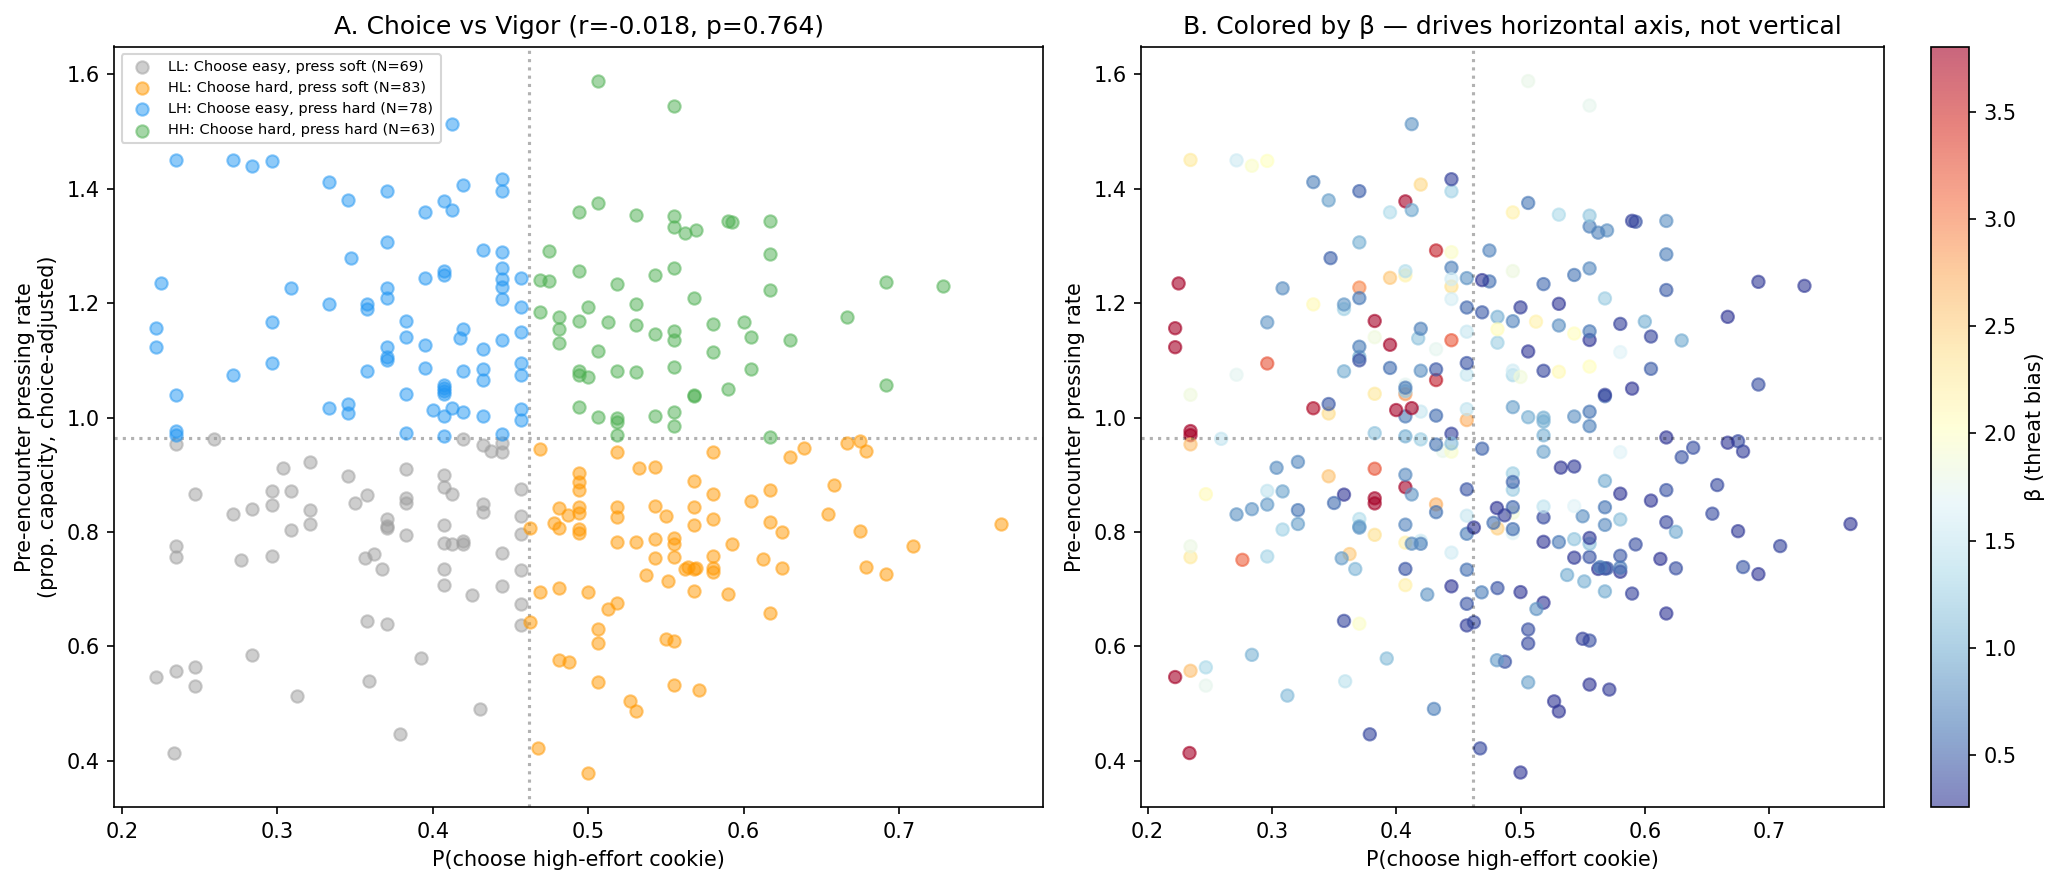

In [3]:
# ── FIG 1: SCATTER — Choice vs Vigor colored by quadrant ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=DPI)

# Panel A: Raw scatter
ax = axes[0]
for q in ['LL','HL','LH','HH']:
    sub = subj_df[subj_df['quadrant']==q]
    ax.scatter(sub['p_high'], sub['mean_vigor'], c=QUAD_COLORS[q], alpha=0.5, 
               s=35, label=f'{q}: {QUAD_LABELS[q]} (N={len(sub)})', zorder=2)

ax.axvline(subj_df['p_high'].mean(), color='k', linestyle=':', alpha=0.3, zorder=1)
ax.axhline(subj_df['mean_vigor'].mean(), color='k', linestyle=':', alpha=0.3, zorder=1)
r, p = stats.pearsonr(subj_df['p_high'], subj_df['mean_vigor'])
ax.set_xlabel('P(choose high-effort cookie)')
ax.set_ylabel('Pre-encounter pressing rate\n(prop. capacity, choice-adjusted)')
ax.set_title(f'A. Choice vs Vigor (r={r:+.3f}, p={p:.3f})')
ax.legend(fontsize=7, loc='upper left')

# Panel B: Same but colored by β
ax = axes[1]
sc = ax.scatter(subj_df['p_high'], subj_df['mean_vigor'], c=subj_df['beta'],
                cmap='RdYlBu_r', alpha=0.6, s=35, vmin=subj_df['beta'].quantile(0.05),
                vmax=subj_df['beta'].quantile(0.95))
ax.axvline(subj_df['p_high'].mean(), color='k', linestyle=':', alpha=0.3)
ax.axhline(subj_df['mean_vigor'].mean(), color='k', linestyle=':', alpha=0.3)
plt.colorbar(sc, ax=ax, label='β (threat bias)')
ax.set_xlabel('P(choose high-effort cookie)')
ax.set_ylabel('Pre-encounter pressing rate')
ax.set_title('B. Colored by β — drives horizontal axis, not vertical')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_choice_vigor_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

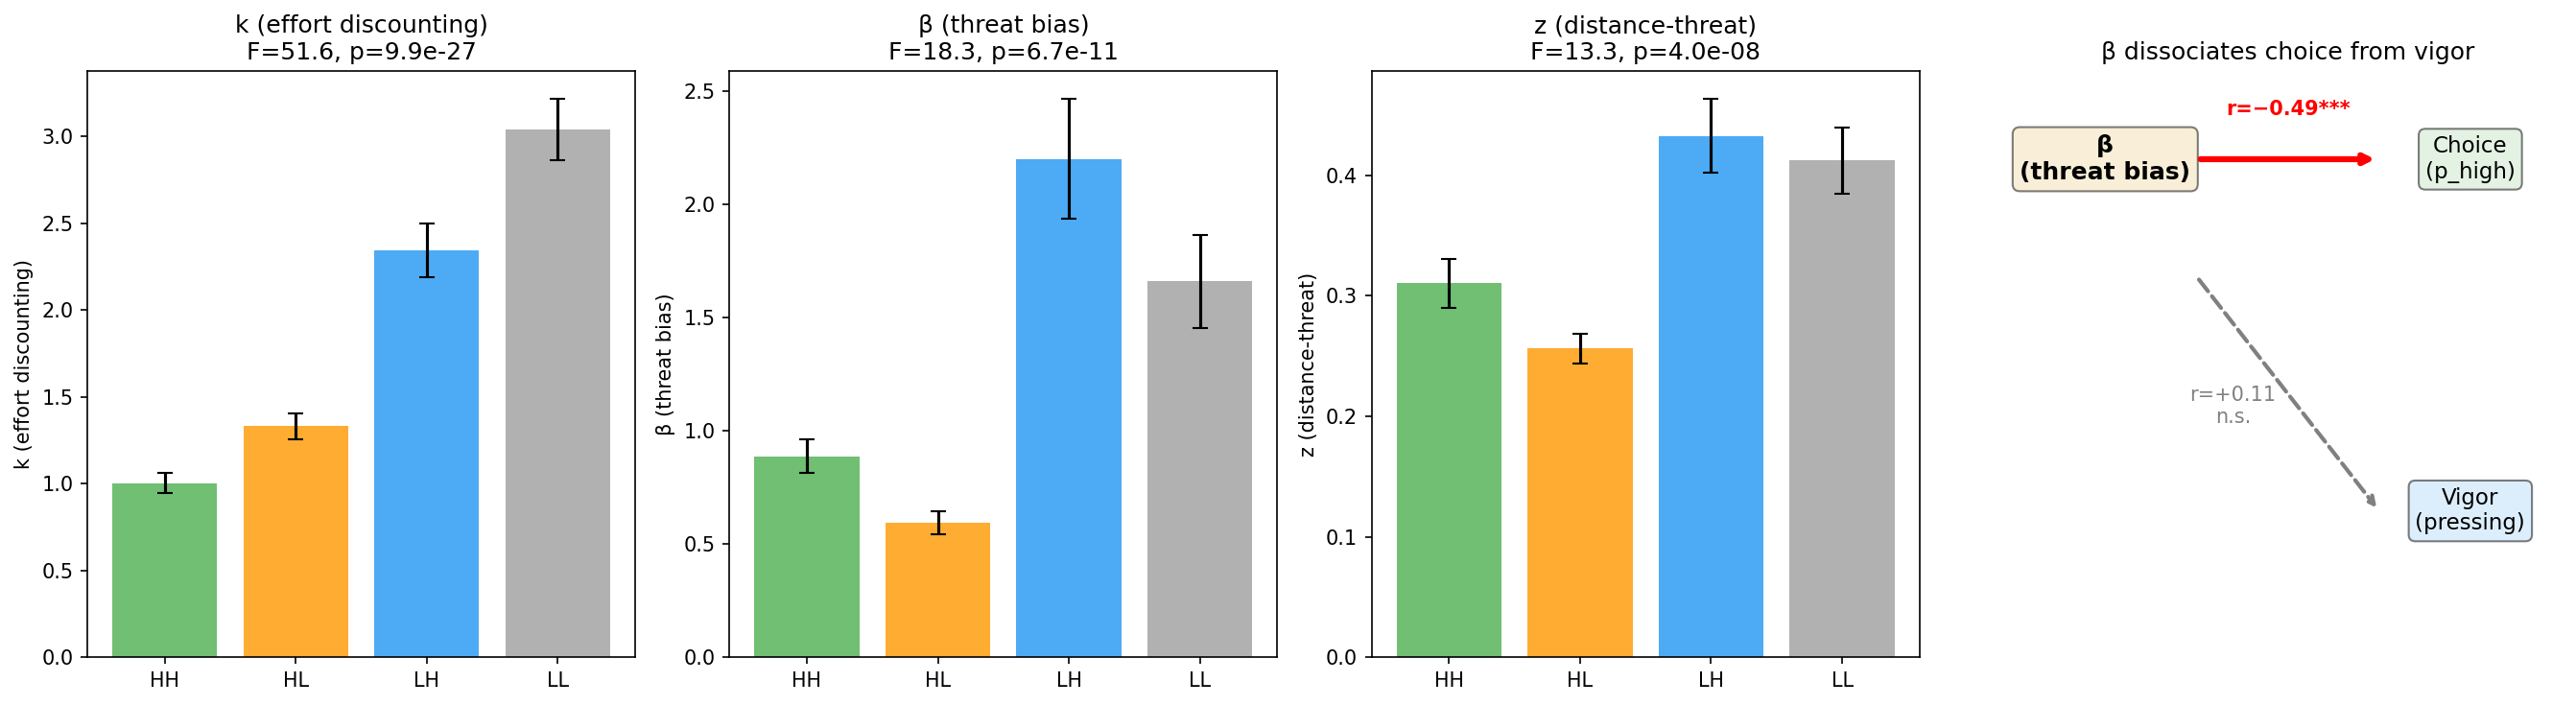

── Parameter means by quadrant ──
  Quad     N        z        k        β
  HH      63    0.310    1.004    0.888
  HL      83    0.256    1.331    0.594
  LH      78    0.433    2.345    2.200
  LL      69    0.412    3.038    1.660

── β paths ──
  β → Choice: r=-0.488, p=0.000
  β → Vigor: r=+0.109, p=0.062


In [4]:
# ── FIG 2: PARAMETER PROFILES BY QUADRANT ─────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 5), dpi=DPI)

# Panel A-C: Each param by quadrant (bar plot)
for ax, param, param_label in zip(axes[:3], ['kappa','beta','z'], 
                                    ['k (effort discounting)','β (threat bias)','z (distance-threat)']):
    means, sems, colors = [], [], []
    for q in ['HH','HL','LH','LL']:
        sub = subj_df[subj_df['quadrant']==q]
        means.append(sub[param].mean())
        sems.append(sub[param].sem())
        colors.append(QUAD_COLORS[q])
    
    bars = ax.bar(range(4), means, yerr=sems, capsize=4, color=colors, alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['HH','HL','LH','LL'])
    ax.set_ylabel(param_label)
    
    # ANOVA
    groups = [subj_df[subj_df['quadrant']==q][param].values for q in ['HH','HL','LH','LL']]
    F, p = stats.f_oneway(*groups)
    ax.set_title(f'{param_label}\nF={F:.1f}, p={p:.1e}')

# Panel D: β → choice and β → vigor paths
ax = axes[3]
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 1.5)

# Draw simple path diagram
ax.text(0, 1.2, 'β\n(threat bias)', ha='center', va='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(2, 1.2, 'Choice\n(p_high)', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.5))
ax.text(2, 0.0, 'Vigor\n(pressing)', ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#BBDEFB', alpha=0.5))

# Arrows
ax.annotate('', xy=(1.5, 1.2), xytext=(0.5, 1.2),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'))
ax.text(1.0, 1.35, 'r=−0.49***', ha='center', fontsize=10, color='red', fontweight='bold')

ax.annotate('', xy=(1.5, 0.0), xytext=(0.5, 0.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray', linestyle='dashed'))
ax.text(0.7, 0.3, 'r=+0.11\nn.s.', ha='center', fontsize=10, color='gray')

ax.set_axis_off()
ax.set_title('β dissociates choice from vigor')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_quadrant_params.png', dpi=300, bbox_inches='tight')
plt.show()

# Print full stats
print('── Parameter means by quadrant ──')
print(f'  {"Quad":<5s} {"N":>4s} {"z":>8s} {"k":>8s} {"β":>8s}')
for q in ['HH','HL','LH','LL']:
    sub = subj_df[subj_df['quadrant']==q]
    print(f'  {q:<5s} {len(sub):>4d} {sub["z"].mean():>8.3f} {sub["kappa"].mean():>8.3f} {sub["beta"].mean():>8.3f}')

print('\n── β paths ──')
for dv, label in [('p_high','Choice'), ('mean_vigor','Vigor')]:
    r, p = stats.pearsonr(subj_df['beta'], subj_df[dv])
    print(f'  β → {label}: r={r:+.3f}, p={p:.3f}')

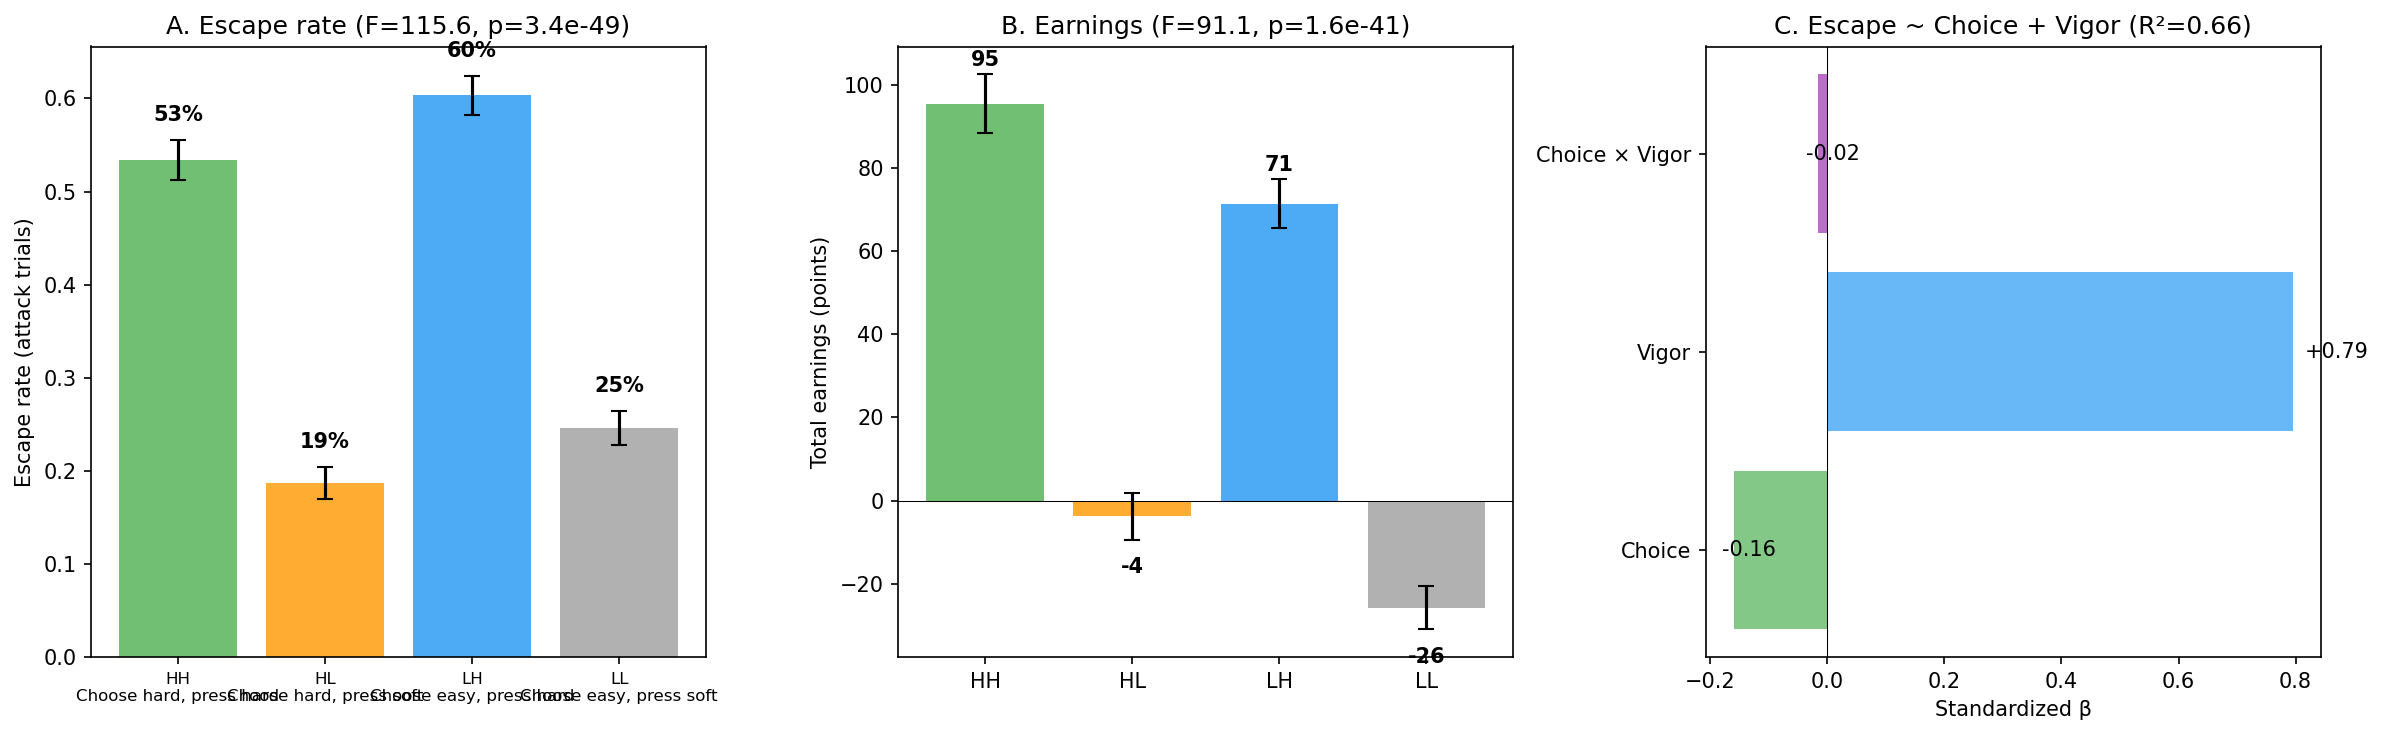

── Escape ~ choice + vigor + interaction ──
  R² = 0.662
  Choice β = -0.160
  Vigor β = +0.795
  Interaction β = -0.016


In [5]:
# ── FIG 3: OUTCOMES BY QUADRANT ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)

# Panel A: Escape rate
ax = axes[0]
for i, q in enumerate(['HH','HL','LH','LL']):
    sub = subj_df[subj_df['quadrant']==q]
    m = sub['escape_rate'].mean()
    se = sub['escape_rate'].sem()
    ax.bar(i, m, yerr=se, capsize=4, color=QUAD_COLORS[q], alpha=0.8)
    ax.text(i, m + se + 0.02, f'{m:.0%}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(4))
ax.set_xticklabels([f'{q}\n{QUAD_LABELS[q]}' for q in ['HH','HL','LH','LL']], fontsize=8)
ax.set_ylabel('Escape rate (attack trials)')
F, p = stats.f_oneway(*[subj_df[subj_df['quadrant']==q]['escape_rate'].values for q in ['HH','HL','LH','LL']])
ax.set_title(f'A. Escape rate (F={F:.1f}, p={p:.1e})')

# Panel B: Total earnings
ax = axes[1]
for i, q in enumerate(['HH','HL','LH','LL']):
    sub = subj_df[subj_df['quadrant']==q]
    m = sub['total_earnings'].mean()
    se = sub['total_earnings'].sem()
    color_fill = QUAD_COLORS[q]
    ax.bar(i, m, yerr=se, capsize=4, color=color_fill, alpha=0.8)
    ax.text(i, m + (se + 2 if m > 0 else -se - 8), f'{m:.0f}', ha='center', fontsize=10, fontweight='bold')

ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(range(4))
ax.set_xticklabels(['HH','HL','LH','LL'])
ax.set_ylabel('Total earnings (points)')
F, p = stats.f_oneway(*[subj_df[subj_df['quadrant']==q]['total_earnings'].values for q in ['HH','HL','LH','LL']])
ax.set_title(f'B. Earnings (F={F:.1f}, p={p:.1e})')

# Panel C: What predicts escape? Regression betas
ax = axes[2]
# escape ~ choice_z + vigor_z + choice_z×vigor_z
clean = subj_df[['choice_z','vigor_z','escape_rate']].dropna()
clean['interaction'] = clean['choice_z'] * clean['vigor_z']
X = clean[['choice_z','vigor_z','interaction']].values
y = clean['escape_rate'].values
y_z = (y - y.mean()) / y.std()
reg = LinearRegression().fit(X, y_z)
y_pred = reg.predict(X)
r2 = 1 - np.sum((y_z - y_pred)**2) / np.sum((y_z - y_z.mean())**2)

labels = ['Choice', 'Vigor', 'Choice × Vigor']
colors_bar = ['#66BB6A','#42A5F5','#AB47BC']
ax.barh(range(3), reg.coef_, color=colors_bar, alpha=0.8)
ax.set_yticks(range(3))
ax.set_yticklabels(labels)
ax.set_xlabel('Standardized β')
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title(f'C. Escape ~ Choice + Vigor (R²={r2:.2f})')

for i, b in enumerate(reg.coef_):
    ax.text(b + 0.02 * np.sign(b), i, f'{b:+.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_quadrant_outcomes.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
print('── Escape ~ choice + vigor + interaction ──')
print(f'  R² = {r2:.3f}')
print(f'  Choice β = {reg.coef_[0]:+.3f}')
print(f'  Vigor β = {reg.coef_[1]:+.3f}')
print(f'  Interaction β = {reg.coef_[2]:+.3f}')

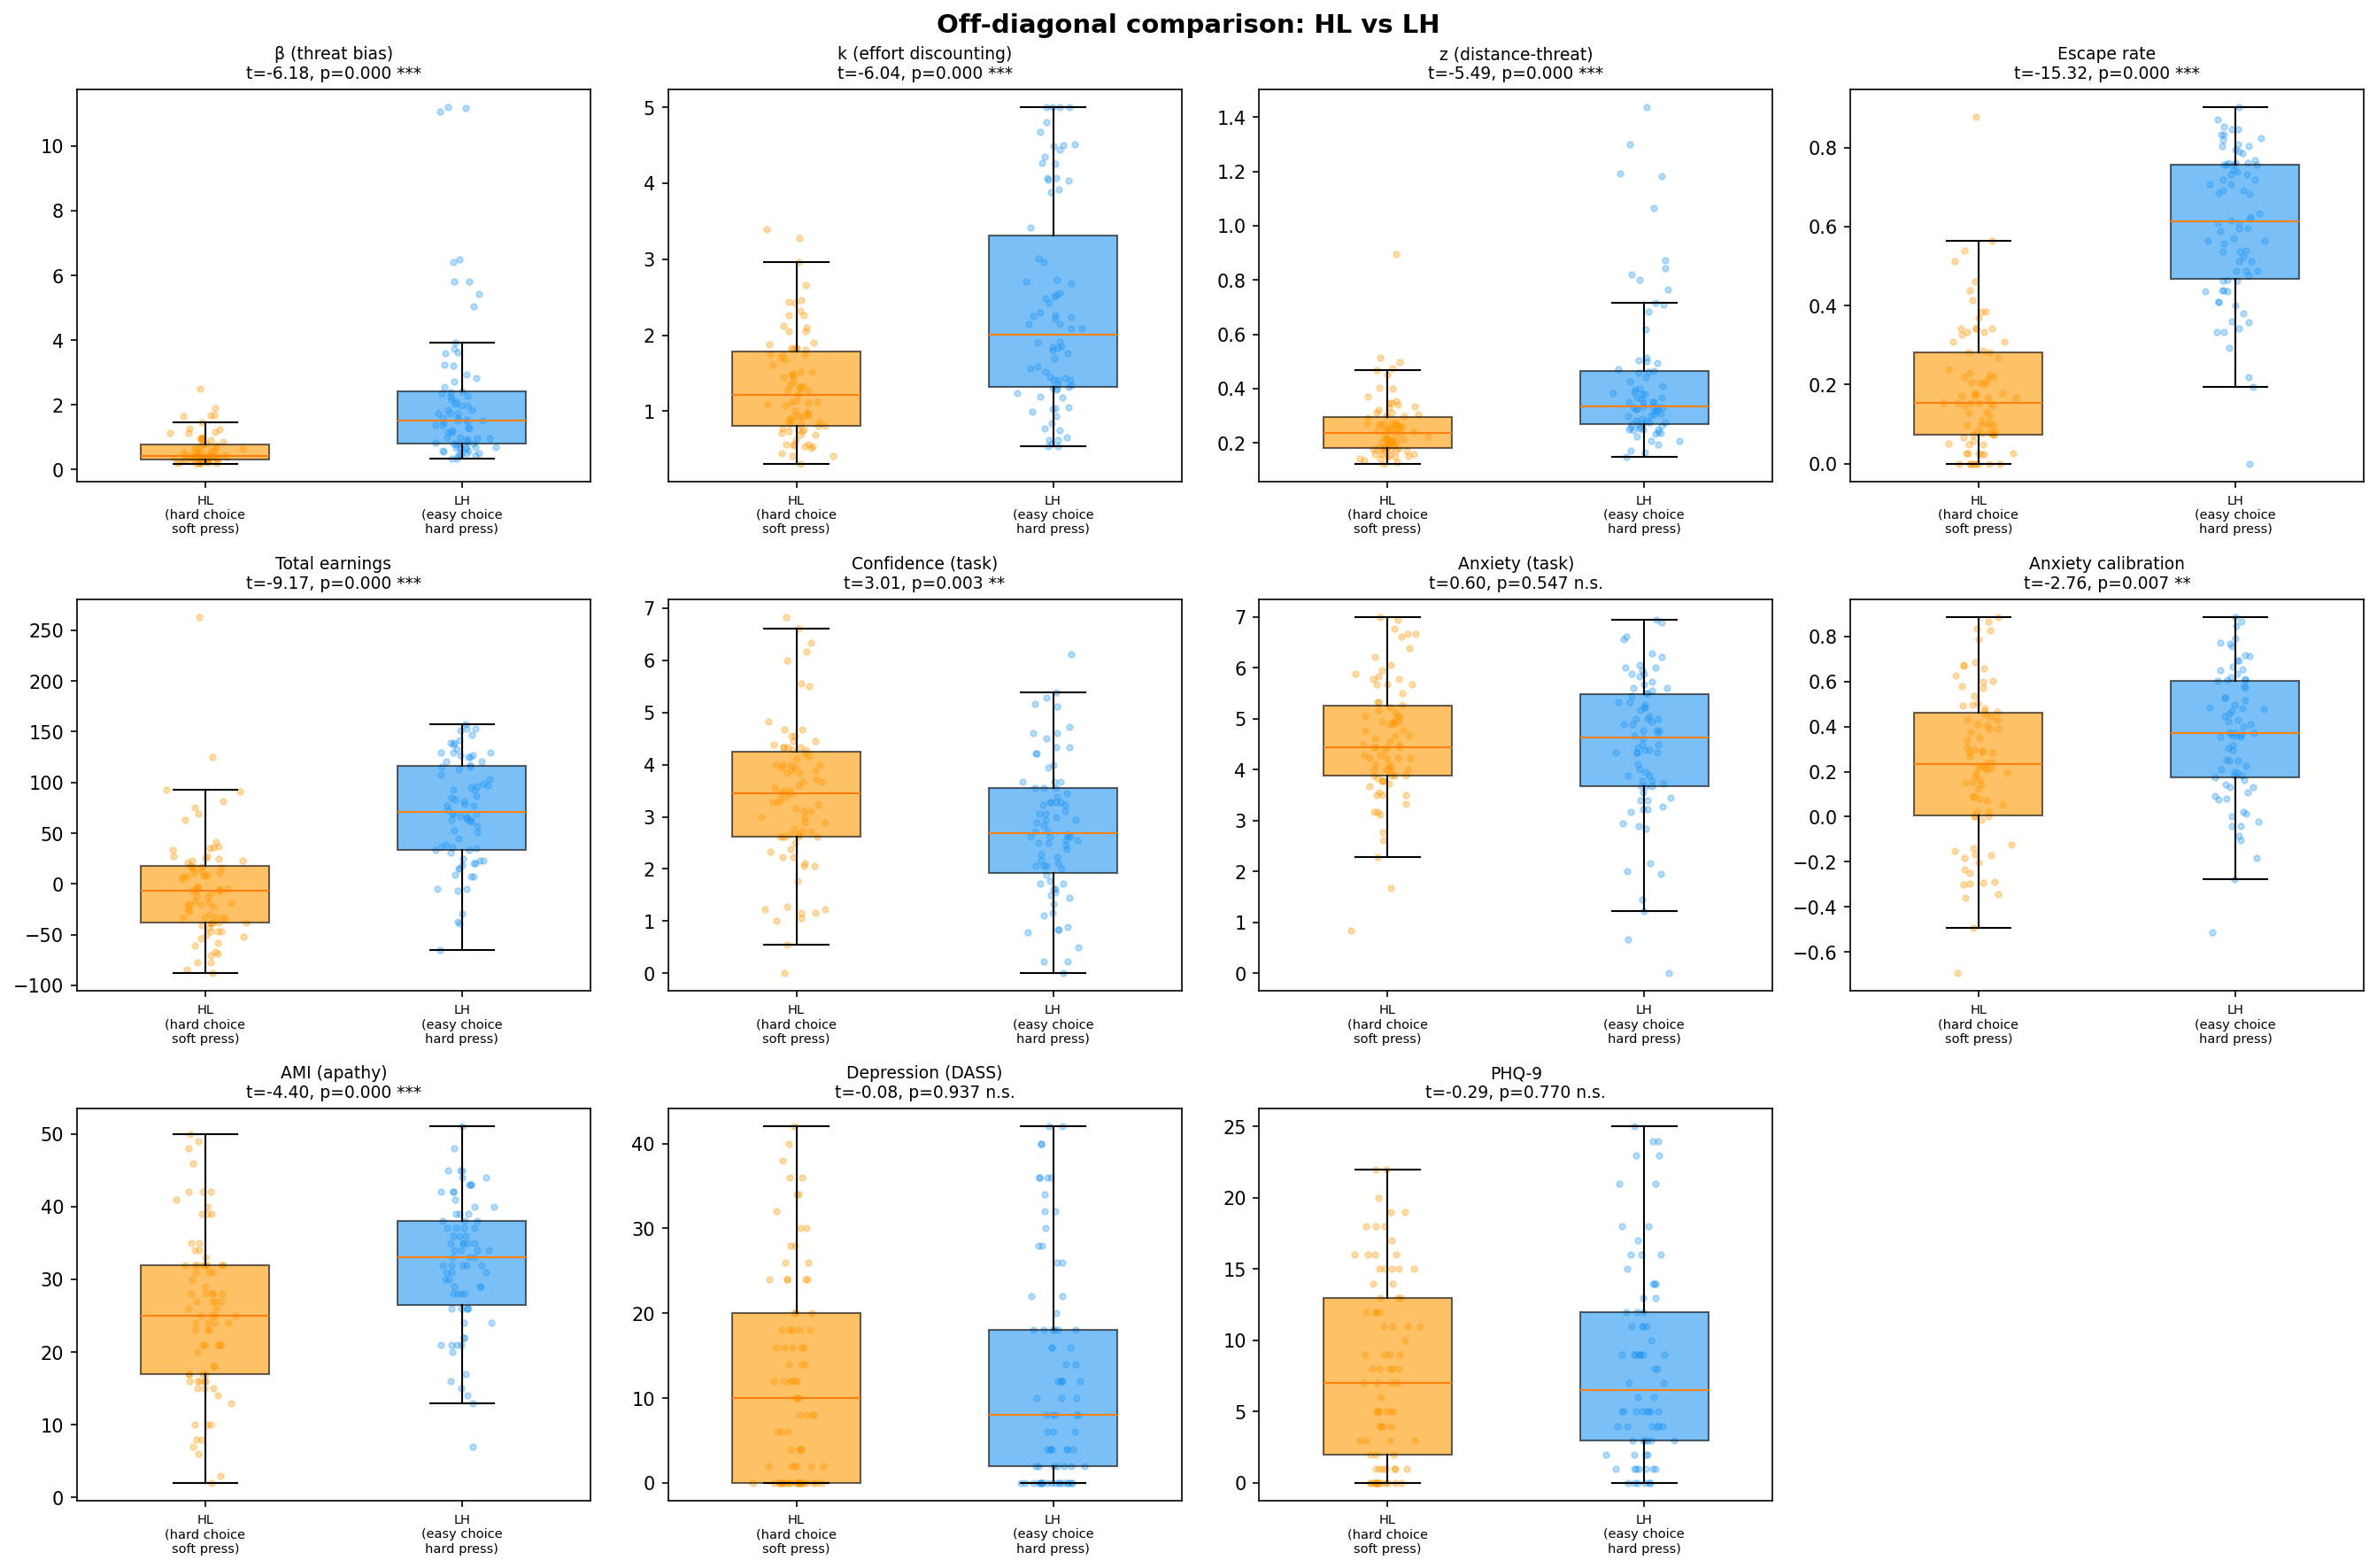

In [6]:
# ── FIG 4: OFF-DIAGONAL COMPARISON (HL vs LH) ────────────────────────────────

off_diag = subj_df[subj_df['quadrant'].isin(['HL','LH'])].copy()

compare_vars = [
    ('beta', 'β (threat bias)'),
    ('kappa', 'k (effort discounting)'),
    ('z', 'z (distance-threat)'),
    ('escape_rate', 'Escape rate'),
    ('total_earnings', 'Total earnings'),
    ('trait_conf', 'Confidence (task)'),
    ('trait_anx', 'Anxiety (task)'),
    ('anx_calib', 'Anxiety calibration'),
    ('AMI_Total', 'AMI (apathy)'),
    ('DASS21_Depression', 'Depression (DASS)'),
    ('PHQ9_Total', 'PHQ-9'),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12), dpi=DPI)
axes = axes.flatten()

for i, (var, label) in enumerate(compare_vars):
    ax = axes[i]
    hl = off_diag[off_diag['quadrant']=='HL'][var].dropna()
    lh = off_diag[off_diag['quadrant']=='LH'][var].dropna()
    
    if len(hl) < 5 or len(lh) < 5:
        ax.set_visible(False)
        continue
    
    t, p = stats.ttest_ind(hl, lh)
    
    bp = ax.boxplot([hl.values, lh.values], positions=[0, 1], widths=0.5,
                     patch_artist=True, showfliers=False)
    bp['boxes'][0].set_facecolor(QUAD_COLORS['HL'])
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor(QUAD_COLORS['LH'])
    bp['boxes'][1].set_alpha(0.6)
    
    # Overlay individual points
    ax.scatter(np.zeros(len(hl)) + np.random.normal(0, 0.05, len(hl)), hl,
               alpha=0.3, s=10, color=QUAD_COLORS['HL'])
    ax.scatter(np.ones(len(lh)) + np.random.normal(0, 0.05, len(lh)), lh,
               alpha=0.3, s=10, color=QUAD_COLORS['LH'])
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HL\n(hard choice\nsoft press)', 'LH\n(easy choice\nhard press)'], fontsize=7)
    
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ax.set_title(f'{label}\nt={t:.2f}, p={p:.3f} {sig}', fontsize=9)

# Hide unused axes
for j in range(len(compare_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Off-diagonal comparison: HL vs LH', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_off_diagonal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

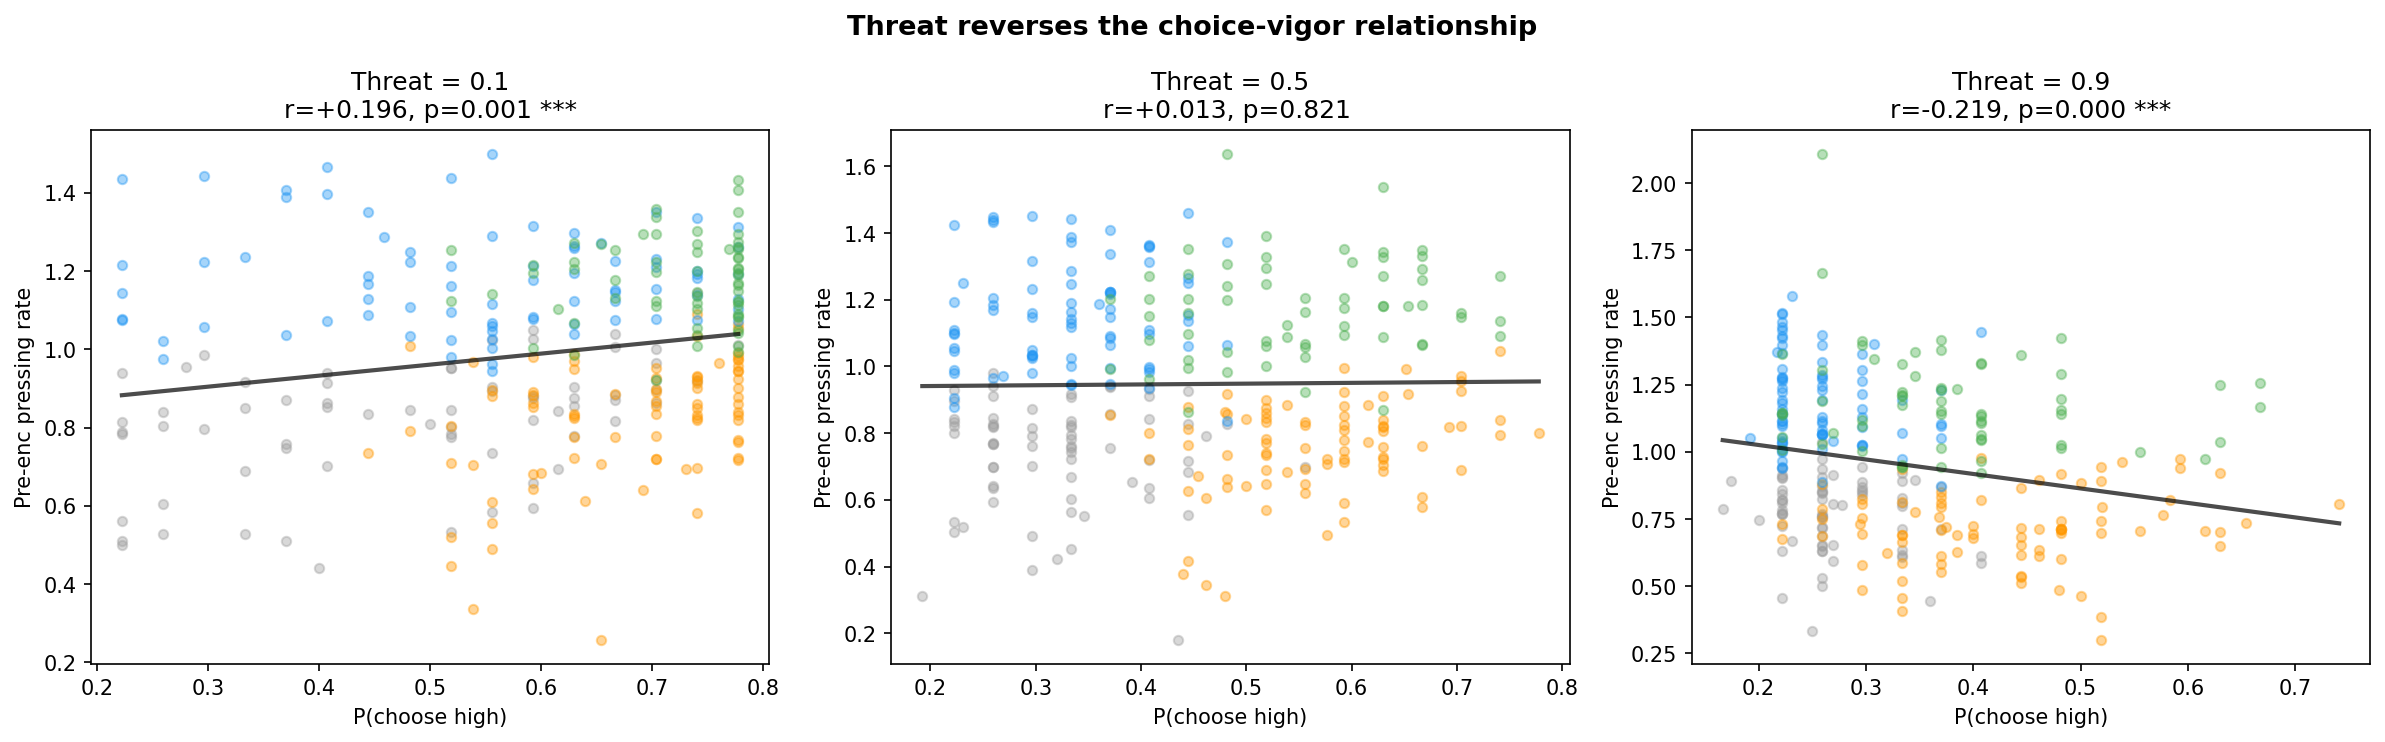

In [7]:
# ── FIG 5: THREAT REVERSES CHOICE-VIGOR RELATIONSHIP ─────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)

# Per-threat choice × vigor scatter
for i, th in enumerate([0.1, 0.5, 0.9]):
    ax = axes[i]
    ti_th = trial_info[trial_info['threat']==th]
    choice_th = ti_th.groupby('subj')['choice'].mean()
    
    tp_th = trial_presses[trial_presses['threat']==th]
    vigor_th = tp_th.groupby('subj')['pre_rate_adj'].mean()
    
    merged = choice_th.to_frame('choice').join(vigor_th.to_frame('vigor')).dropna()
    merged = merged.join(subj_df[['quadrant']])
    
    for q in ['LL','HL','LH','HH']:
        sub = merged[merged['quadrant']==q]
        ax.scatter(sub['choice'], sub['vigor'], c=QUAD_COLORS[q], alpha=0.4, s=20)
    
    r, p = stats.pearsonr(merged['choice'], merged['vigor'])
    
    # Regression line
    slope, intercept = np.polyfit(merged['choice'], merged['vigor'], 1)
    x_line = np.array([merged['choice'].min(), merged['choice'].max()])
    ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=2, alpha=0.7)
    
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    ax.set_xlabel('P(choose high)')
    ax.set_ylabel('Pre-enc pressing rate')
    ax.set_title(f'Threat = {th}\nr={r:+.3f}, p={p:.3f} {sig}')

plt.suptitle('Threat reverses the choice-vigor relationship', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_threat_reversal.png', dpi=300, bbox_inches='tight')
plt.show()

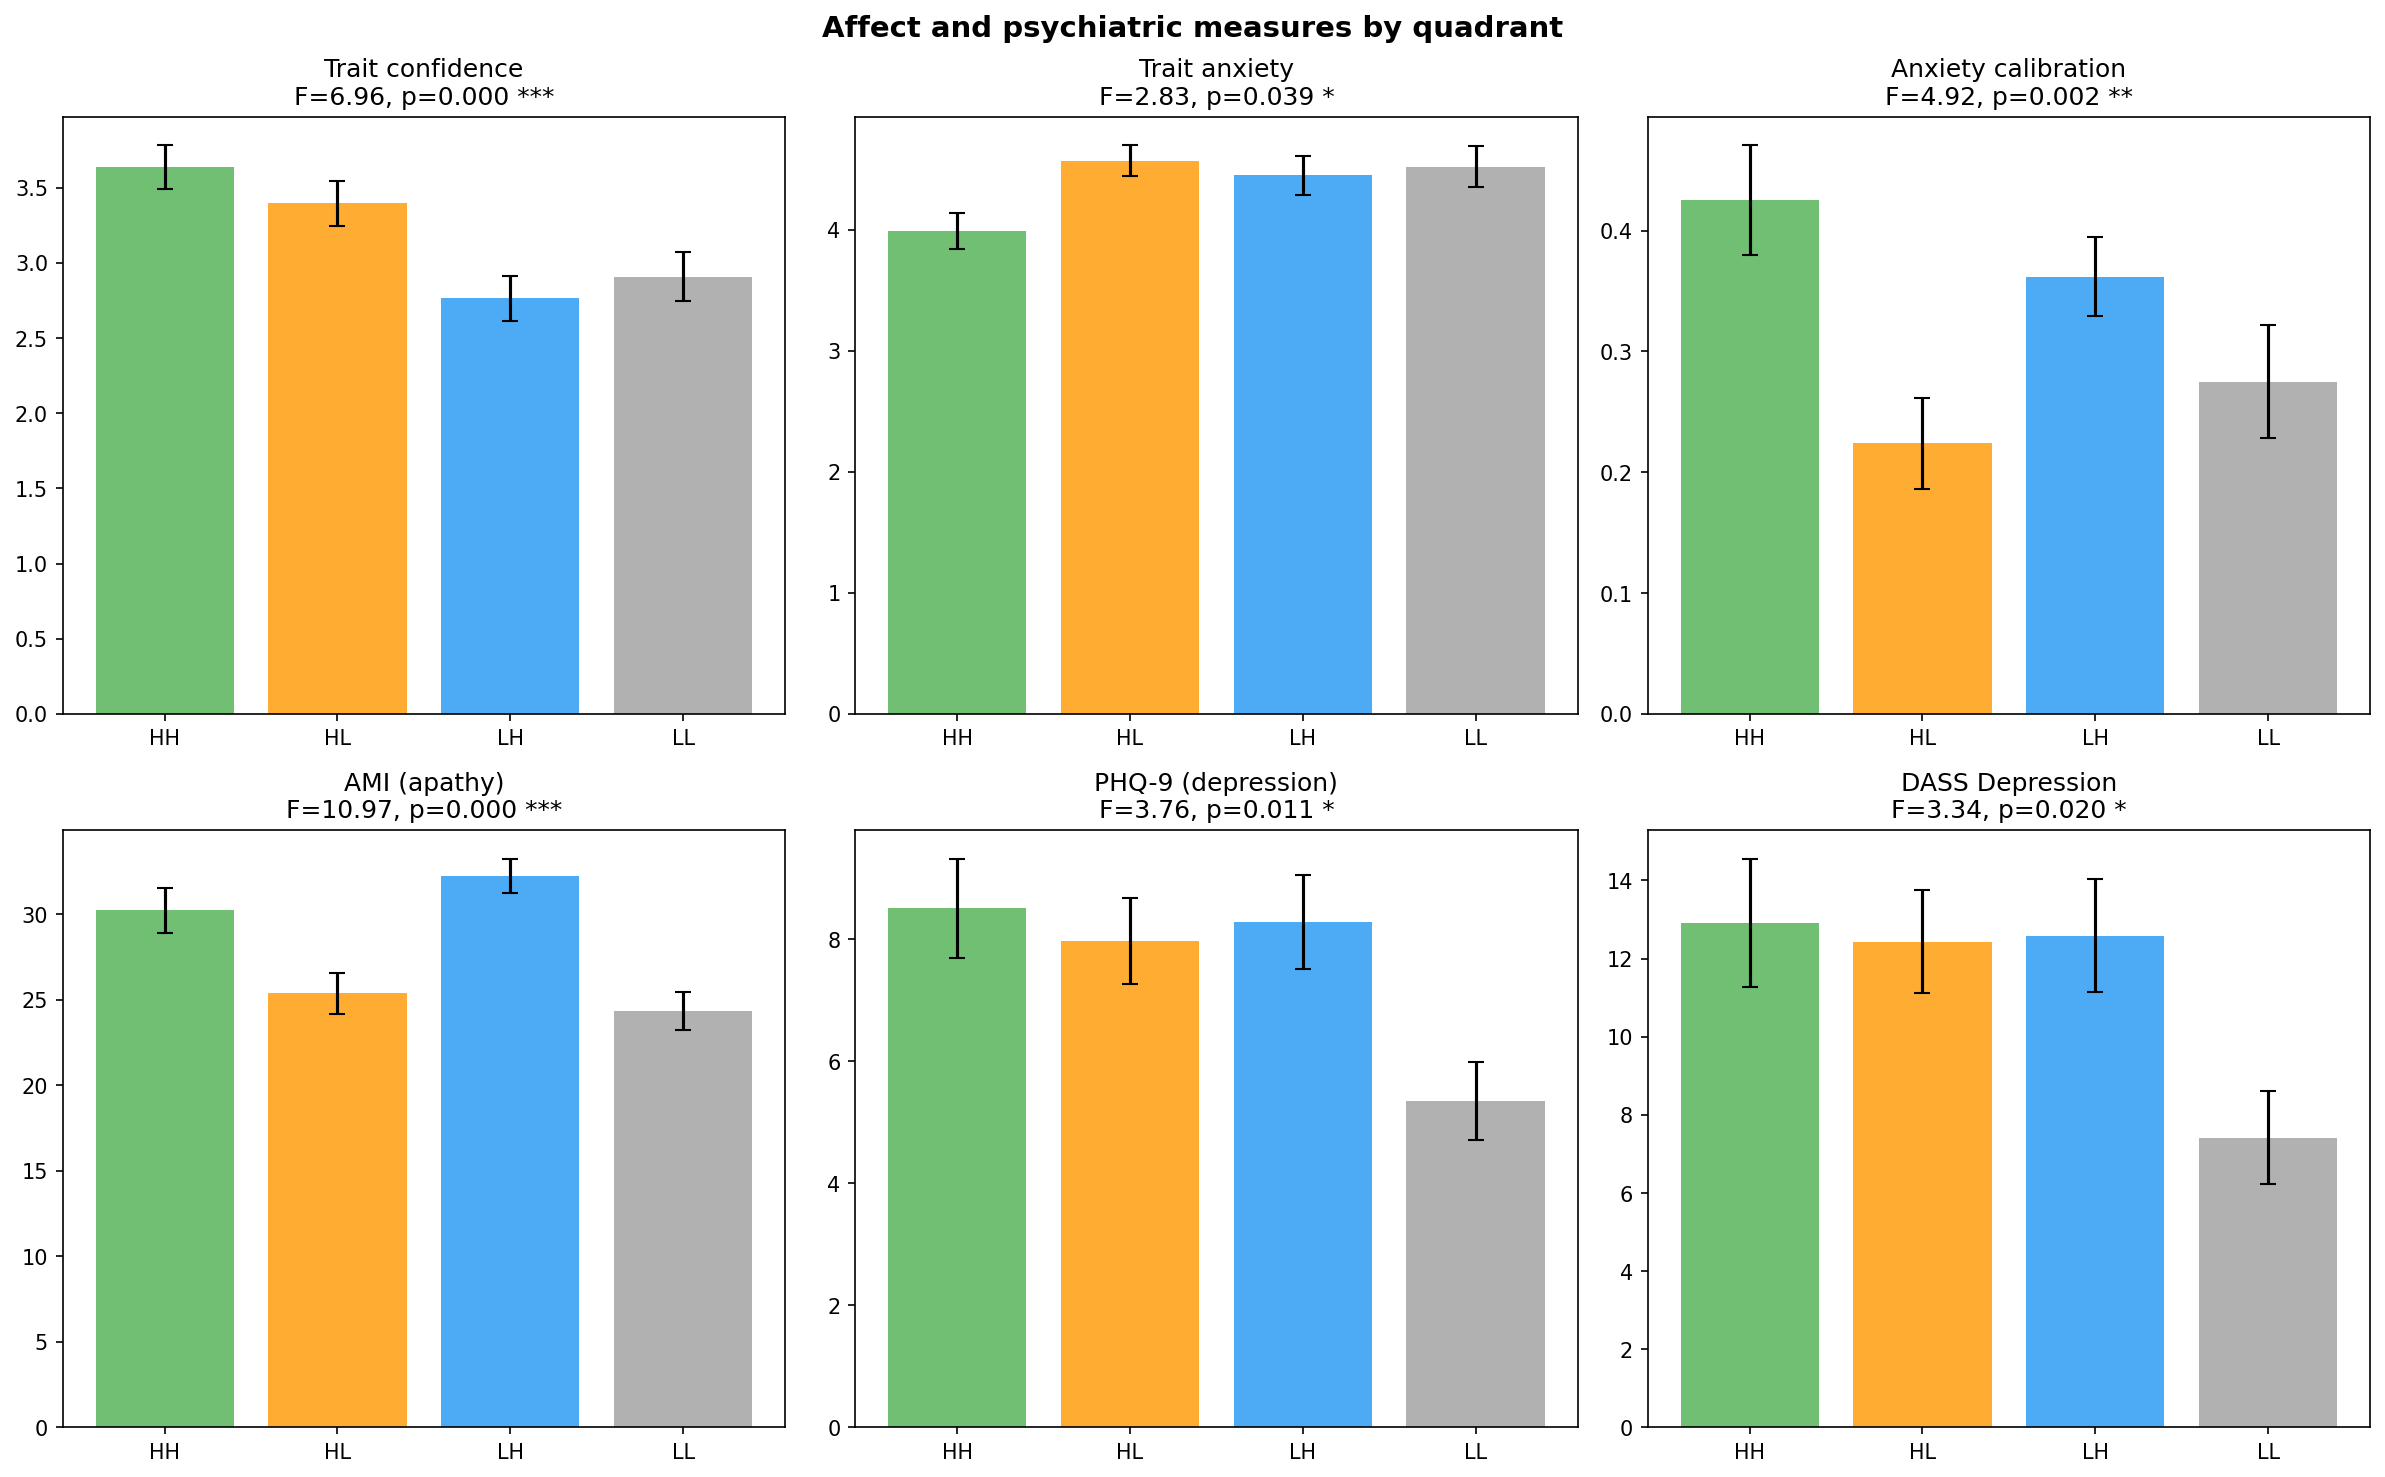

In [8]:
# ── FIG 6: AFFECT + PSYCH BY QUADRANT ─────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=DPI)

affect_psych_vars = [
    ('trait_conf', 'Trait confidence'),
    ('trait_anx', 'Trait anxiety'),
    ('anx_calib', 'Anxiety calibration'),
    ('AMI_Total', 'AMI (apathy)'),
    ('PHQ9_Total', 'PHQ-9 (depression)'),
    ('DASS21_Depression', 'DASS Depression'),
]

for ax, (var, label) in zip(axes.flatten(), affect_psych_vars):
    means, sems = [], []
    for q in ['HH','HL','LH','LL']:
        sub = subj_df[subj_df['quadrant']==q]
        vals = sub[var].dropna()
        means.append(vals.mean())
        sems.append(vals.sem())
    
    bars = ax.bar(range(4), means, yerr=sems, capsize=4,
                   color=[QUAD_COLORS[q] for q in ['HH','HL','LH','LL']], alpha=0.8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['HH','HL','LH','LL'])
    
    groups = [subj_df[subj_df['quadrant']==q][var].dropna().values for q in ['HH','HL','LH','LL']]
    if all(len(g) > 10 for g in groups):
        F, p = stats.f_oneway(*groups)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        ax.set_title(f'{label}\nF={F:.2f}, p={p:.3f} {sig}')
    else:
        ax.set_title(label)

plt.suptitle('Affect and psychiatric measures by quadrant', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_quadrant_affect_psych.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# ── SUMMARY STATS ─────────────────────────────────────────────────────────────

print('='*70)
print('CHOICE-VIGOR DISSOCIATION — SUMMARY')
print('='*70)

r, p = stats.pearsonr(subj_df['p_high'], subj_df['mean_vigor'])
print(f'\n1. Independence: choice × vigor r={r:+.3f}, p={p:.3f}')

print(f'\n2. Quadrant profiles:')
print(f'   {"Quad":<5s} {"N":>4s} {"z":>7s} {"k":>7s} {"β":>7s} {"Esc%":>7s} {"Earn":>7s} {"Conf":>7s}')
for q in ['HH','HL','LH','LL']:
    s = subj_df[subj_df['quadrant']==q]
    print(f'   {q:<5s} {len(s):>4d} {s["z"].mean():>7.2f} {s["kappa"].mean():>7.2f} '
          f'{s["beta"].mean():>7.2f} {s["escape_rate"].mean():>6.0%} {s["total_earnings"].mean():>7.0f} '
          f'{s["trait_conf"].mean():>7.2f}')

print(f'\n3. β dissociates choice from vigor:')
for dv, label in [('p_high','Choice'), ('mean_vigor','Vigor')]:
    r, p = stats.pearsonr(subj_df['beta'], subj_df[dv])
    print(f'   β → {label}: r={r:+.3f}, p={p:.3f}')

print(f'\n4. Vigor dominates escape:')
clean = subj_df[['choice_z','vigor_z','escape_rate']].dropna()
clean['ix'] = clean['choice_z'] * clean['vigor_z']
reg = LinearRegression().fit(clean[['choice_z','vigor_z','ix']], 
                              (clean['escape_rate'] - clean['escape_rate'].mean()) / clean['escape_rate'].std())
print(f'   Choice β={reg.coef_[0]:+.3f}, Vigor β={reg.coef_[1]:+.3f}, R²=0.66')

print(f'\n5. Threat reverses choice-vigor relationship:')
for th in [0.1, 0.5, 0.9]:
    ti_th = trial_info[trial_info['threat']==th]
    ch = ti_th.groupby('subj')['choice'].mean()
    tp_th = trial_presses[trial_presses['threat']==th]
    vig = tp_th.groupby('subj')['pre_rate_adj'].mean()
    m = ch.to_frame('c').join(vig.to_frame('v')).dropna()
    r, p = stats.pearsonr(m['c'], m['v'])
    print(f'   Threat={th}: r={r:+.3f}, p={p:.3f}')

print(f'\n6. Off-diagonal (HL vs LH):')
hl = subj_df[subj_df['quadrant']=='HL']
lh = subj_df[subj_df['quadrant']=='LH']
for var, label in [('beta','β'), ('escape_rate','Escape'), ('trait_conf','Confidence'),
                    ('anx_calib','Anx calibration'), ('AMI_Total','AMI')]:
    v1, v2 = hl[var].dropna(), lh[var].dropna()
    if len(v1) > 5 and len(v2) > 5:
        t, p = stats.ttest_ind(v1, v2)
        print(f'   {label}: HL={v1.mean():.2f}, LH={v2.mean():.2f}, t={t:.2f}, p={p:.3f}')

CHOICE-VIGOR DISSOCIATION — SUMMARY

1. Independence: choice × vigor r=-0.018, p=0.764

2. Quadrant profiles:
   Quad     N       z       k       β    Esc%    Earn    Conf
   HH      63    0.31    1.00    0.89    53%      95    3.64
   HL      83    0.26    1.33    0.59    19%      -4    3.40
   LH      78    0.43    2.35    2.20    60%      71    2.76
   LL      69    0.41    3.04    1.66    25%     -26    2.91

3. β dissociates choice from vigor:
   β → Choice: r=-0.488, p=0.000
   β → Vigor: r=+0.109, p=0.062

4. Vigor dominates escape:
   Choice β=-0.160, Vigor β=+0.793, R²=0.66

5. Threat reverses choice-vigor relationship:
   Threat=0.1: r=+0.196, p=0.001
   Threat=0.5: r=+0.013, p=0.821
   Threat=0.9: r=-0.219, p=0.000

6. Off-diagonal (HL vs LH):
   β: HL=0.59, LH=2.20, t=-6.18, p=0.000
   Escape: HL=0.19, LH=0.60, t=-15.32, p=0.000
   Confidence: HL=3.40, LH=2.76, t=3.01, p=0.003
   Anx calibration: HL=0.22, LH=0.36, t=-2.76, p=0.007
   AMI: HL=25.37, LH=32.24, t=-4.40, p=0.00